<a href="https://colab.research.google.com/github/adombe/Machine_Learning_2026-/blob/main/Exercise_3_AVCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Perform a univariate analysis of the 'temp_ann' variable from the `EFIplus_medit.csv` dataset. First, identify and filter the dataset for the four catchments with the highest number of fish sampling sites. Then, for these top four catchments, generate strip plots, histograms, and boxplots of 'temp_ann'. Additionally, analyze how the sample mean of 'temp_ann' varies with increasing sample size by performing a sampling experiment. Finally, provide a summary of the univariate analysis, evaluate the pros and cons of the generated visualizations, and discuss the findings from the sample mean variation analysis, identifying the sample size needed for a good estimate of the population mean.

## Load Data and Identify Top Catchments

### Subtask:
Load the 'EFIplus_medit.csv' dataset. Identify the four catchments with the highest number of fish sampling sites. Filter the dataset to include only these top four catchments for subsequent analysis.


**Reasoning**:
First, I'll import the pandas library to handle data manipulation. Then, I will load the 'EFIplus_medit.csv' dataset into a DataFrame named `df` as instructed. Afterwards, I will calculate the sum of 'fish_sites' for each 'catchment' and identify the top four catchments. Finally, I will filter the original DataFrame to include only these top catchments and display the first few rows of the filtered DataFrame.



In [5]:
import pandas as pd

df = pd.read_csv('/content/EFIplus_medit.csv', sep=';')


In [ ]:
df.head()

,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
0,ES_01_0002,38.102003,-4.096070,Spain,Guadalquivir,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [6]:
# Count occurrences of each Catchment_name and get the top 4
top_catchments_data = df['Catchment_name'].value_counts().nlargest(4)
top_catchment_names = top_catchments_data.index.tolist()

# Filter the original DataFrame to include only these top four catchments
df_filtered = df[df['Catchment_name'].isin(top_catchment_names)]

print("Top 4 catchments by row count:\n", top_catchments_data)
print("\nFiltered DataFrame head:")
display(df_filtered.head())

Top 4 catchments by row count:
 Catchment_name
Ebro            736
Galiza-Norte    709
Minho           707
Tejo            509
Name: count, dtype: int64

Filtered DataFrame head:


,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
5,ES_02_0005,40.732830,-2.078003,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [8]:
# Check for missing values in the temperature variable
print(f"Missing values in temp_ann: {df_filtered['temp_ann'].isnull().sum()}")
print(f"Total rows in filtered data: {len(df_filtered)}")

# If there are missing values, decide how to handle them
df_plot = df_filtered.dropna(subset=['temp_ann']).copy()
print(f"Rows after dropping NA in temp_ann: {len(df_plot)}")

Missing values in temp_ann: 37
Total rows in filtered data: 2661
Rows after dropping NA in temp_ann: 2624


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

# Get the catchment names
catchments = top_catchment_names
print(f"Plotting for catchments: {catchments}")

Plotting for catchments: ['Ebro', 'Galiza-Norte', 'Minho', 'Tejo']


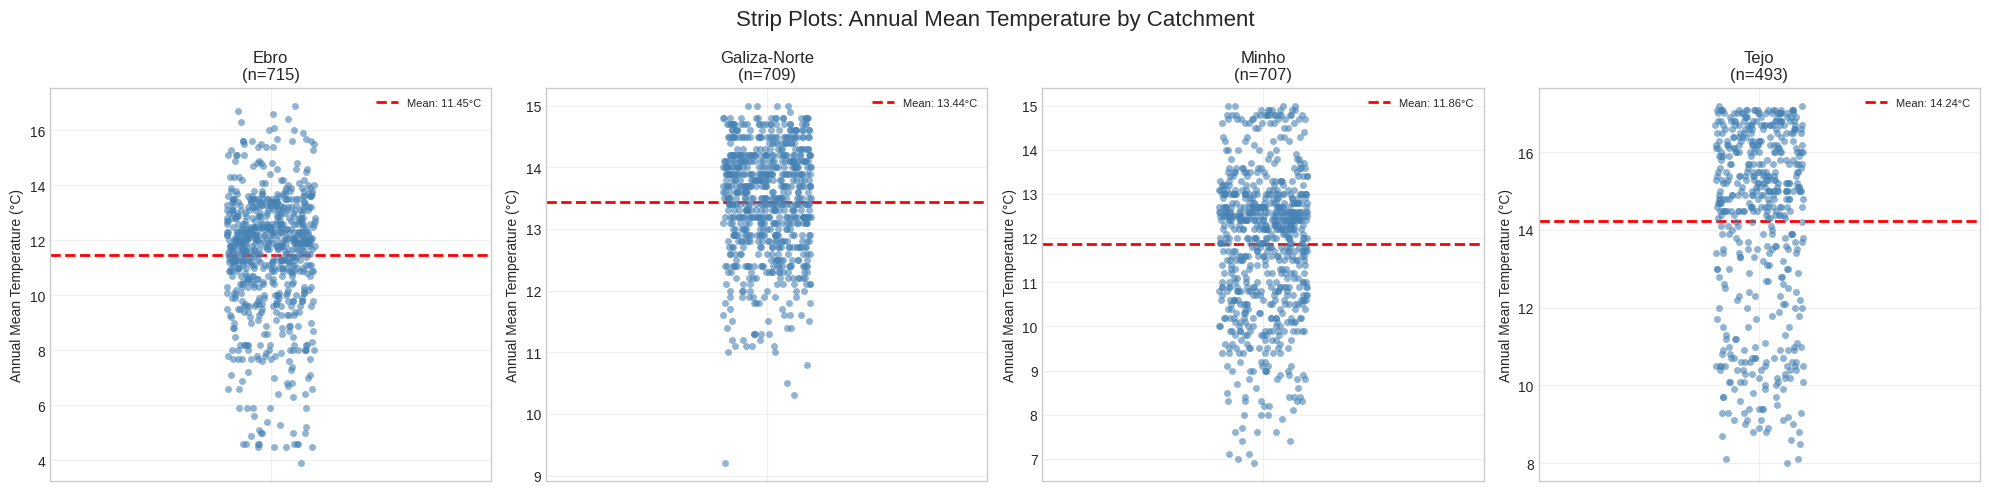

In [11]:
# Create strip plots
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Strip Plots: Annual Mean Temperature by Catchment', fontsize=16)

for i, catchment in enumerate(catchments):
    # Get data for this catchment
    catchment_data = df_plot[df_plot['Catchment_name'] == catchment]['temp_ann'].dropna()

    # Create strip plot
    sns.stripplot(y=catchment_data, ax=axes[i], color='steelblue', alpha=0.6, jitter=True)

    # Add mean line
    mean_val = catchment_data.mean()
    axes[i].axhline(y=mean_val, color='red', linestyle='--', linewidth=2,
                   label=f'Mean: {mean_val:.2f}°C')

    # Customize
    axes[i].set_title(f'{catchment}\n(n={len(catchment_data)})')
    axes[i].set_ylabel('Annual Mean Temperature (°C)')
    axes[i].legend(loc='best', fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

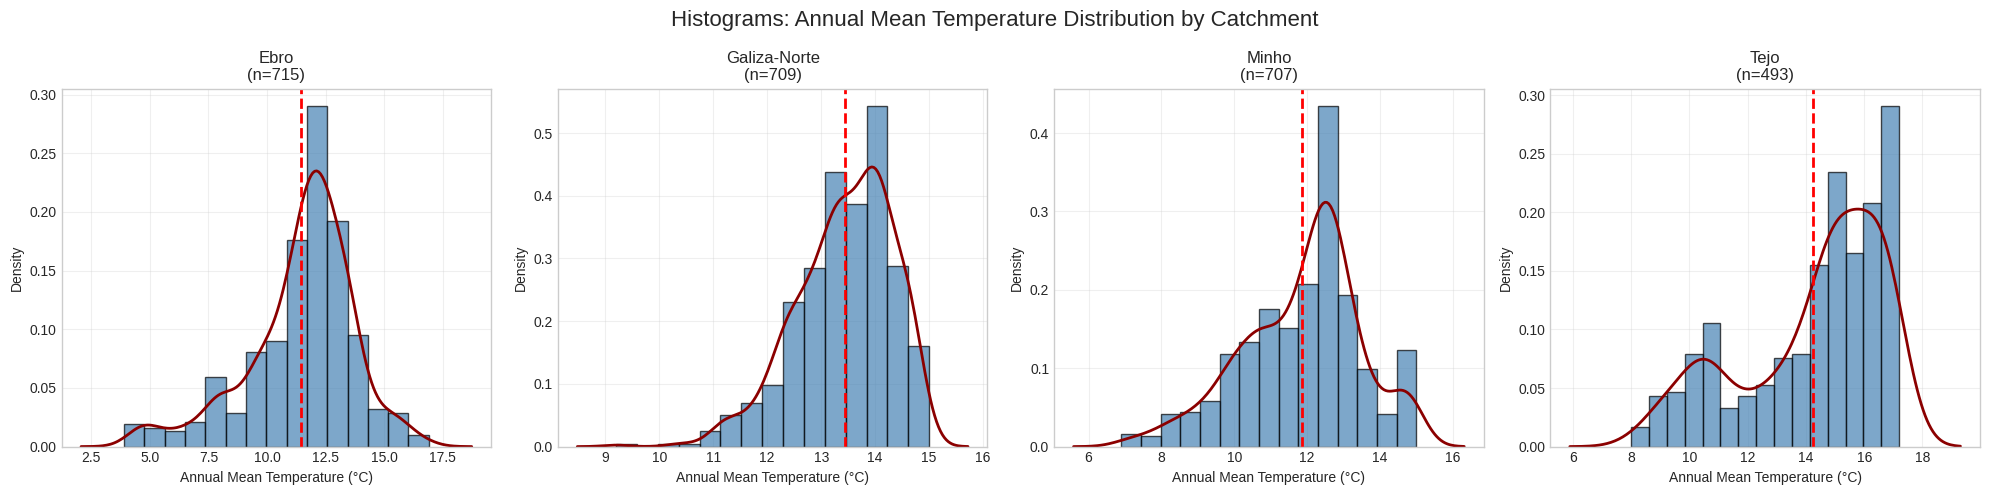

In [12]:
# Create histograms
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Histograms: Annual Mean Temperature Distribution by Catchment', fontsize=16)

for i, catchment in enumerate(catchments):
    # Get data for this catchment
    catchment_data = df_plot[df_plot['Catchment_name'] == catchment]['temp_ann'].dropna()

    # Create histogram
    axes[i].hist(catchment_data, bins=15, color='steelblue', edgecolor='black',
                alpha=0.7, density=True)

    # Add KDE
    sns.kdeplot(data=catchment_data, color='darkred', linewidth=2, ax=axes[i])

    # Add mean line
    mean_val = catchment_data.mean()
    axes[i].axvline(x=mean_val, color='red', linestyle='--', linewidth=2)

    # Customize
    axes[i].set_title(f'{catchment}\n(n={len(catchment_data)})')
    axes[i].set_xlabel('Annual Mean Temperature (°C)')
    axes[i].set_ylabel('Density')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

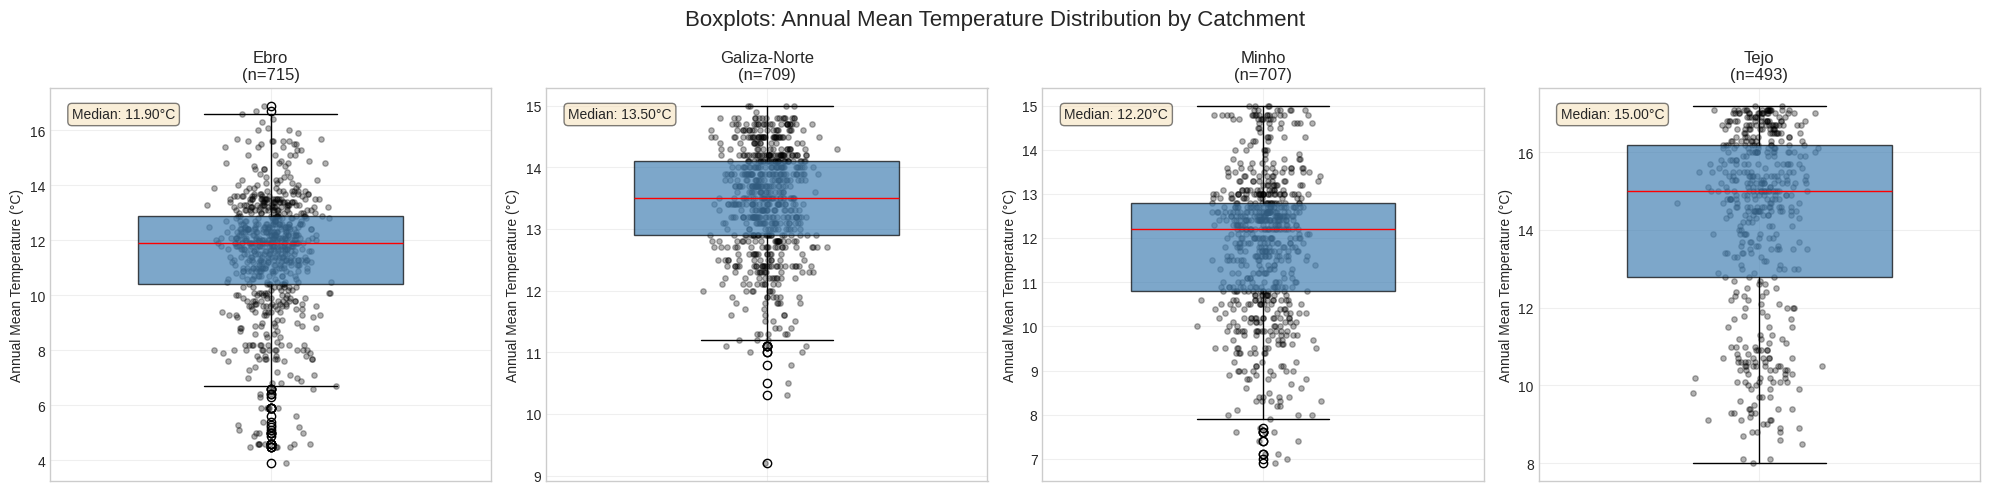

In [13]:
# Create boxplots
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Boxplots: Annual Mean Temperature Distribution by Catchment', fontsize=16)

for i, catchment in enumerate(catchments):
    # Get data for this catchment
    catchment_data = df_plot[df_plot['Catchment_name'] == catchment]['temp_ann'].dropna()

    # Create boxplot
    bp = axes[i].boxplot(catchment_data, patch_artist=True, widths=0.6)

    # Customize colors
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][0].set_alpha(0.7)
    bp['medians'][0].set_color('red')

    # Add individual points (optional)
    y = catchment_data
    x = np.random.normal(1, 0.05, size=len(y))
    axes[i].scatter(x, y, alpha=0.3, color='black', s=15)

    # Add statistics
    axes[i].text(0.05, 0.95, f'Median: {np.median(catchment_data):.2f}°C',
                transform=axes[i].transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # Customize
    axes[i].set_title(f'{catchment}\n(n={len(catchment_data)})')
    axes[i].set_ylabel('Annual Mean Temperature (°C)')
    axes[i].set_xticklabels([''])
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

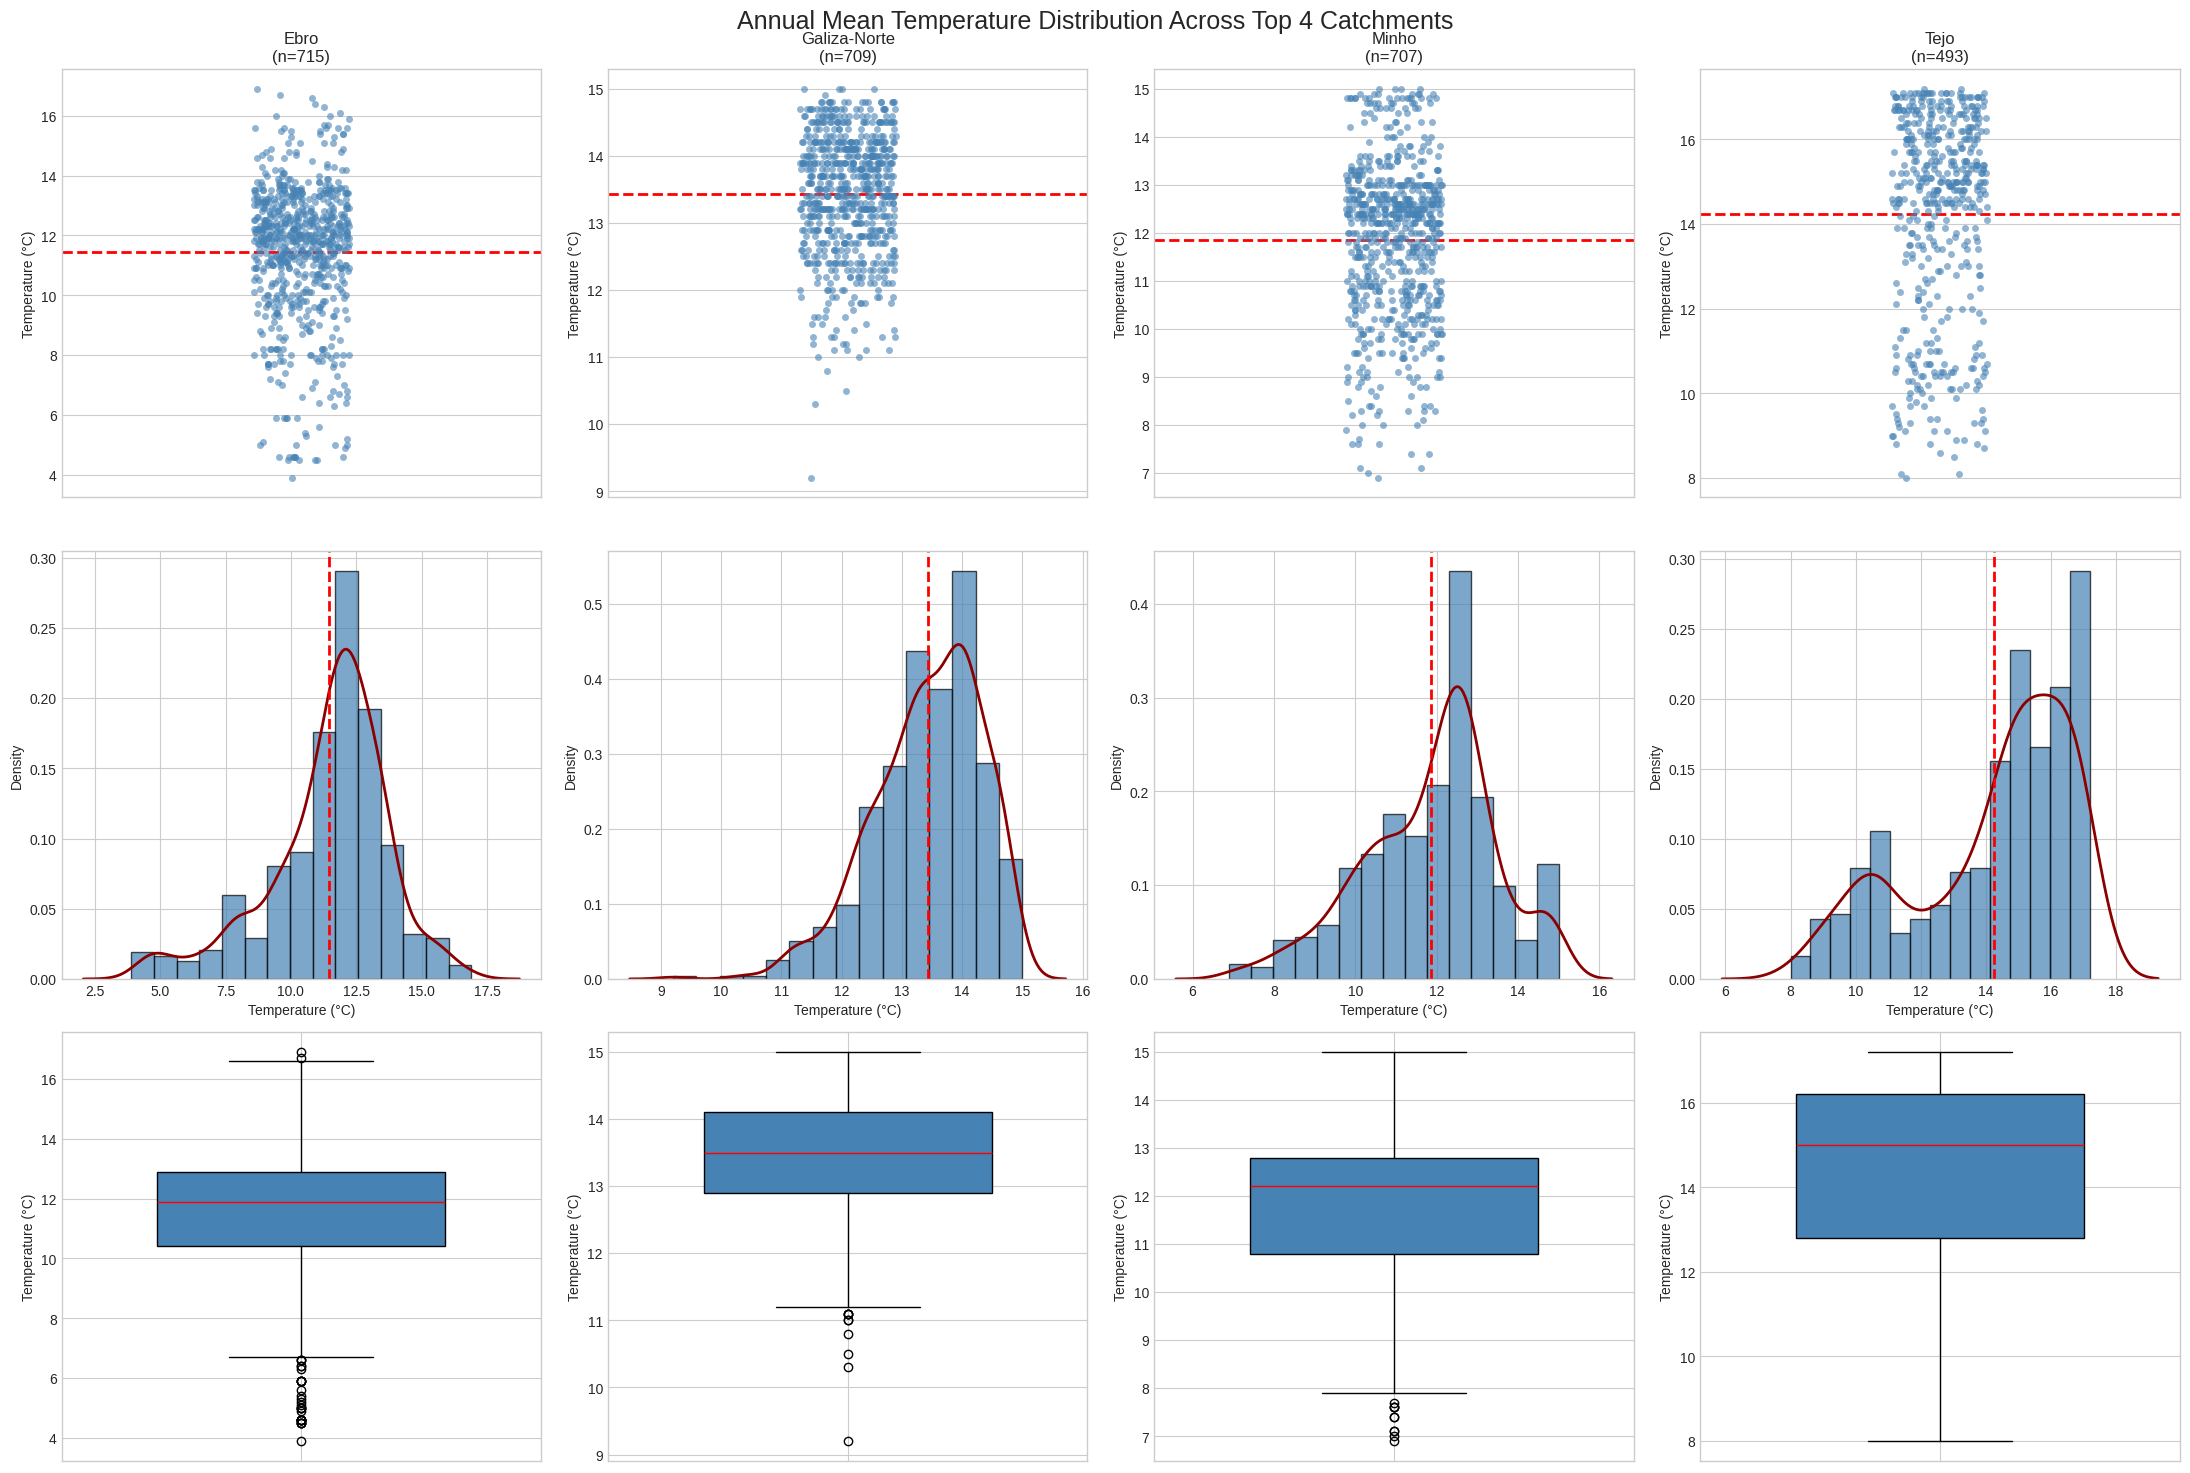

In [14]:
# Create combined figure
fig, axes = plt.subplots(3, 4, figsize=(22, 15))
fig.suptitle('Annual Mean Temperature Distribution Across Top 4 Catchments', fontsize=18)

for i, catchment in enumerate(catchments):
    catchment_data = df_plot[df_plot['Catchment_name'] == catchment]['temp_ann'].dropna()
    mean_val = catchment_data.mean()

    # Row 0: Strip plots
    ax = axes[0, i]
    sns.stripplot(y=catchment_data, ax=ax, color='steelblue', alpha=0.6, jitter=True)
    ax.axhline(y=mean_val, color='red', linestyle='--', linewidth=2)
    ax.set_title(f'{catchment}\n(n={len(catchment_data)})')
    ax.set_ylabel('Temperature (°C)')

    # Row 1: Histograms
    ax = axes[1, i]
    ax.hist(catchment_data, bins=15, color='steelblue', edgecolor='black', alpha=0.7, density=True)
    sns.kdeplot(data=catchment_data, color='darkred', linewidth=2, ax=ax)
    ax.axvline(x=mean_val, color='red', linestyle='--', linewidth=2)
    ax.set_xlabel('Temperature (°C)')
    ax.set_ylabel('Density')

    # Row 2: Boxplots
    ax = axes[2, i]
    bp = ax.boxplot(catchment_data, patch_artist=True, widths=0.6)
    bp['boxes'][0].set_facecolor('steelblue')
    bp['medians'][0].set_color('red')
    ax.set_ylabel('Temperature (°C)')
    ax.set_xticklabels([''])

plt.tight_layout()
plt.subplots_adjust(top=0.94)
plt.show()